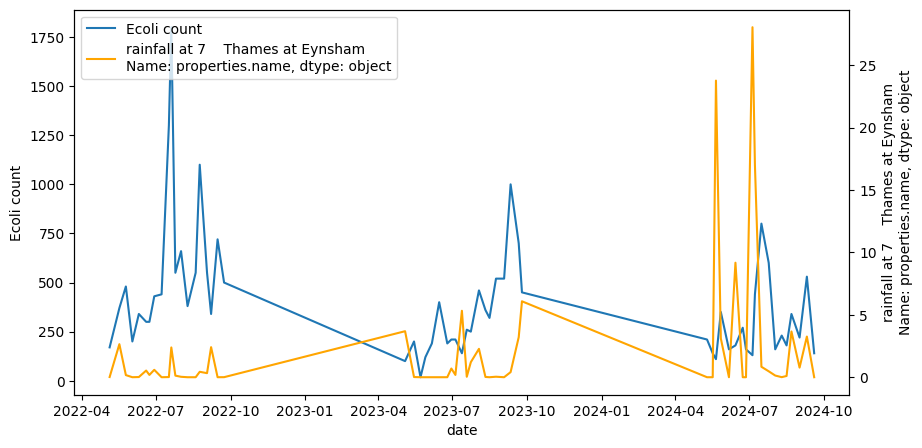

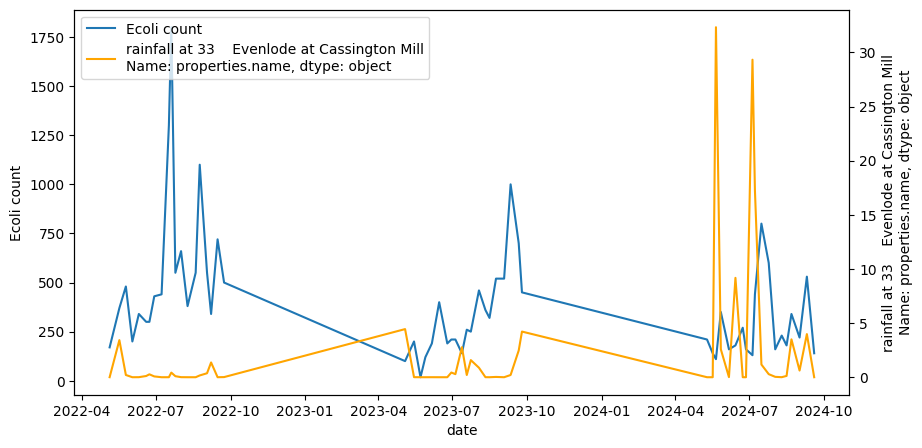

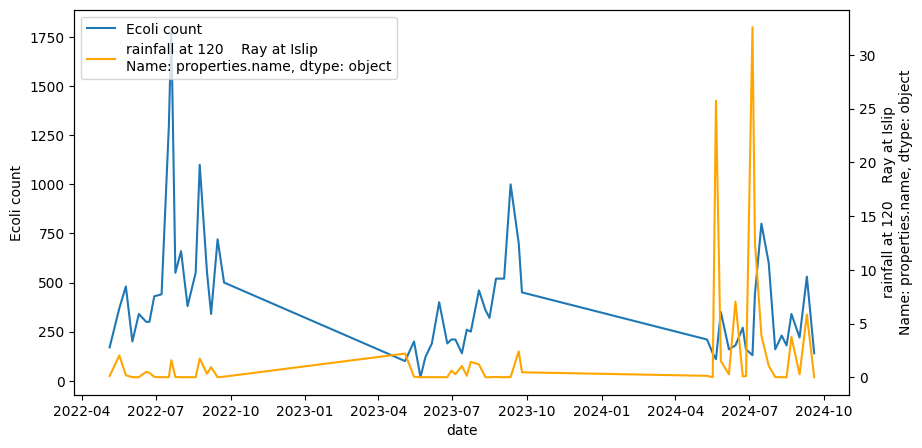

In [109]:
from matplotlib import pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame

import app
import pandas as pd
import geopandas as gpd

from app import df_timeseries_Oxford_fft

ecoli_timeseries_dfs = app.get_ecoli_datasets()
wolvercote_ecoli_timeseries = ecoli_timeseries_dfs[("11946", "ea_bathing_water")]

# get site info for Wolvercote
wolvercote_site_id = "11946"
ecoli_data_set_wolvercote = "ea_bathing_water"
df_ea_bathing_water_site = app.get_sites_for_dataset_as_pandas("ea_bathing_water")
gdf_ea_bathing_water_site = gpd.GeoDataFrame(df_ea_bathing_water_site)
wolvercote_coordinates = gdf_ea_bathing_water_site[gdf_ea_bathing_water_site["properties.id"]==wolvercote_site_id]["geometry.coordinates"]

# get rainfall sites
df_sites_rainfall = app.get_sites_for_dataset_as_pandas("rainfall", display=False)
gdf_sites_rainfall = gpd.GeoDataFrame(df_sites_rainfall)

# find rainfall sites near Wolvercote
from geopy.distance import geodesic
sites_close_to_wolvercote = []
max_distance_km = 8 # 8km
for idx, rainfall_site in gdf_sites_rainfall.iterrows():
    distance_in_km = geodesic(rainfall_site.loc["geometry.coordinates"], wolvercote_coordinates).km
    if distance_in_km < max_distance_km:
            sites_close_to_wolvercote.append(rainfall_site.loc["properties.id"])
# print(sites_close_to_wolvercote) # gives ids ["39008", "39034", "39140"]

# just to experiment, take the rainfall data from "39008", Thames at Eynsham
rainfall_timeseries_rainfall_eynsham = app.get_timeseries_for_dataset_and_site_as_pandas("39008", "rainfall")

# helper functions
def convert_datetime_to_date_with_resampling(df: pd.DataFrame):
    new_df = df.copy()
    new_df["date"] = pd.to_datetime(new_df["datetime"]).dt.date
    new_df["date"] = pd.to_datetime(new_df["date"])
    new_df.set_index('date')
    return new_df

def merge_on_date(df1: pd.DataFrame, df2: pd.DataFrame):
    result = df1.copy()
    result = result.merge(df2, on='date', how='left').dropna()
    return result

def plot_values_vs_date(merged: pd.DataFrame, x: str, y1: str, y2: str, xlabel: str, y1label: str, y2label: str):
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(merged[x], merged[y1], label=y1label)
    ax1.set_ylabel(y1label)
    ax2 = ax1.twinx()
    ax2.plot(merged[x], merged[y2], color='orange', label=y2label)
    ax2.set_ylabel(y2label)
    plt.title("")
    ax1.set_xlabel(xlabel)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    plt.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    plt.show()

# Now do it for all rainfall sites nearby
wolvercote_ecoli_resampled = convert_datetime_to_date_with_resampling(wolvercote_ecoli_timeseries)
for site in sites_close_to_wolvercote:
    rainfall_timeseries = app.get_timeseries_for_dataset_and_site_as_pandas(site, "rainfall")
    rainfall_resampled = convert_datetime_to_date_with_resampling(rainfall_timeseries)
    merged = merge_on_date(wolvercote_ecoli_resampled, rainfall_resampled)
    site_name = df_sites_rainfall[df_sites_rainfall["properties.id"] == site]["properties.name"]
    plot_values_vs_date(merged, "date", 'escherichia coli count', "value", "date", "Ecoli count", "rainfall at {0}".format(site_name))


In [ ]:
# Try for fft too
df_timeseries_Oxford_fft = app.get_timeseries_for_dataset_and_site_as_pandas("Oxford", "fft", display=False)
df_timeseries_Oxford_fft_resampled = convert_datetime_to_date_with_resampling(df_timeseries_Oxford_fft)
merged = merge_on_date(wolvercote_ecoli_resampled, df_timeseries_Oxford_fft_resampled)
plot_values_vs_date(merged, "date", 'escherichia coli count', "value", "date", "Ecoli count", "fft at Oxford")

In [112]:
# Other possible determinands
determinands = app.get_determinands_as_pandas(display=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         29 non-null     object
 1   color        29 non-null     object
 2   description  29 non-null     object
 3   datasets     29 non-null     object
 4   thresholds   8 non-null      object
dtypes: object(5)
memory usage: 1.3+ KB
None
                                               name      color  \
0              Alkalinity to pH 4.5 as CaCO3 (mg/l)    #e31a1c   
1                    Ammonia un-ionised as N (mg/l)    #fb9a99   
2                                   Ammonium (mg/L)    #fdbf6f   
3                   Ammoniacal Nitrogen as N (mg/l)    #a6cee3   
4                            Blue-Green Algae (RFU)      green   
5   Carbon, Organic, Dissolved as C :- {DOC} (mg/l)    #6a3d9a   
6                                   Chloride (mg/l)    #fdbf6f   
7                                Chlor

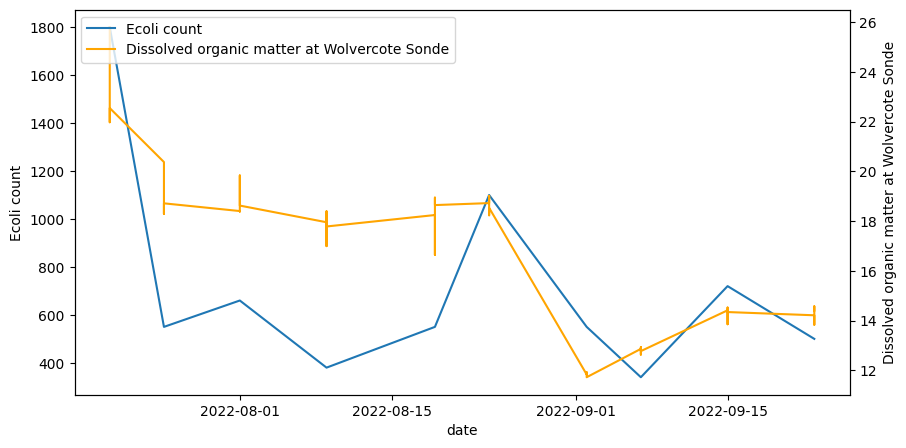

In [108]:
# Might be interested in dissolved organic solids
organic = determinands[determinands["name"]=="Fluorescent Dissolved Organic Matter (RFU)"]["datasets"]
# yields dataset: ea_wq_sonde, determinand: fdom
# use wolvercote site: E01612A
df_organic_sonde_wolvercote = app.get_timeseries_for_dataset_site_determinand_as_pandas("E01612A", "ea_wq_sonde", "fdom", display=False)
df_organic_sonde_wolvercote_resampled = convert_datetime_to_date_with_resampling(df_organic_sonde_wolvercote)
merged = merge_on_date(wolvercote_ecoli_resampled, df_organic_sonde_wolvercote_resampled)
plot_values_vs_date(merged, "date", 'escherichia coli count', "value", "date", "Ecoli count", "Dissolved organic matter at Wolvercote Sonde")


                   datetime  value
0       2025-11-21T11:00:00  0.108
1       2025-11-21T10:45:00  0.109
2       2025-11-21T10:30:00  0.117
3       2025-11-21T10:15:00  0.116
4       2025-11-21T10:00:00  0.120
...                     ...    ...
174861  2021-01-02T01:00:00 -0.021
174862  2021-01-02T00:45:00 -0.018
174863  2021-01-02T00:30:00  0.008
174864  2021-01-02T00:15:00 -0.013
174865  2021-01-02T00:00:00 -0.011

[174866 rows x 2 columns]
Index(['datetime', 'value', 'date'], dtype='object')
Index(['escherichia coli count', 'escherichia coli qualifier',
       'intestinal enterococci count', 'intestinal enterococci qualifier',
       'datetime_x', 'date', 'datetime_y', 'value'],
      dtype='object')


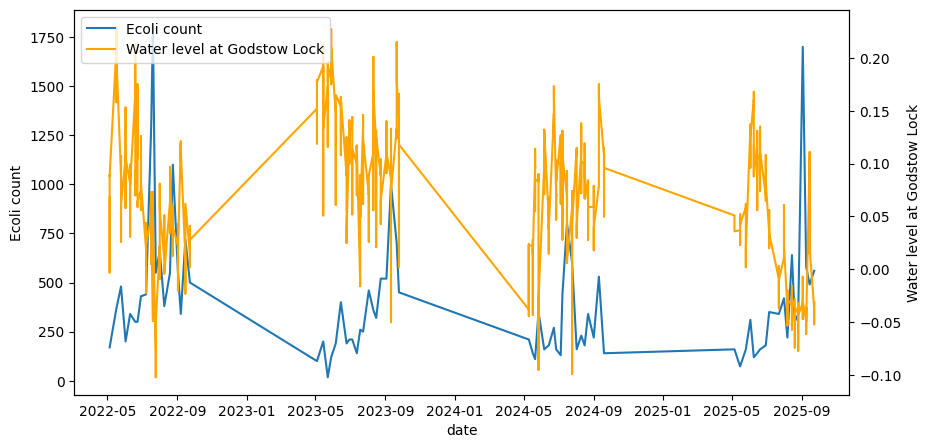

In [107]:
# Might be interested in water level
flow = determinands[determinands["name"]=="Water level"]["datasets"]
# yields dataset: ea_lf_sonde, determinand: waterLevel
sites_sonde_lf = app.get_sites_for_dataset_as_pandas("ea_lf_sonde", display=False)
# use godstow lock site: 7500ccb3-dc3b-49fb-ac42-241fd7ab908c
df_flow_sonde_godstow = app.get_timeseries_for_dataset_site_determinand_as_pandas("7500ccb3-dc3b-49fb-ac42-241fd7ab908c", "ea_lf_sonde", "waterLevel", display=False)
print(df_flow_sonde_godstow)
df_flow_sonde_godstow_resampled = convert_datetime_to_date_with_resampling(df_flow_sonde_godstow)
print(df_flow_sonde_godstow_resampled.columns)
merged = merge_on_date(wolvercote_ecoli_resampled, df_flow_sonde_godstow_resampled)
print(merged.columns)
plot_values_vs_date(merged, "date", 'escherichia coli count', "value", "date", "Ecoli count", "Water level at Godstow Lock")

In [126]:
# # Might be interested in Suspended solids (mg/l)
# solids = determinands[determinands["name"]=="Suspended solids (mg/l)"]["datasets"]
# print(solids)
# # yields dataset: thames_initiative, determinand: Suspended solids mg/L
# sites_solids = app.get_sites_for_dataset_as_pandas("thames_initiative", display=True)
# # use islip site id: Ray at Islip
# df_solids_islip = app.get_timeseries_for_dataset_site_determinand_as_pandas("Ray at Islip", "thames_initiative", "Suspended solids mg/L", display=True)
# # df_flow_sonde_godstow_resampled = convert_datetime_to_date_with_resampling(df_flow_sonde_godstow)
# # merged = merge_on_date(wolvercote_ecoli_resampled, df_flow_sonde_godstow_resampled)
# # plot_values_vs_date(merged, "date", 'escherichia coli count', "value", "date", "Ecoli count", "Water level at Godstow Lock")

25    [{'code': 'thames_initiative', 'id': 'Suspende...
Name: datasets, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   type                  12 non-null     object
 1   geometry.type         12 non-null     object
 2   geometry.coordinates  12 non-null     object
 3   properties.id         12 non-null     object
 4   properties.name       12 non-null     object
 5   properties.code       12 non-null     object
dtypes: object(6)
memory usage: 708.0+ bytes
None
       type geometry.type    geometry.coordinates              properties.id  \
0   Feature         Point  [-1.115066, 51.740372]          Thame at Wheatley   
1   Feature         Point  [-1.236807, 51.821247]               Ray at Islip   
2   Feature         Point   [-1.27724, 51.833191]  Cherwell at Hampton Poyle   
3   Feature         Point  [-1.697669, 51.

FileNotFoundError: [Errno 2] No such file or directory: 'timeseries_data/timeseries_Ray at Islip_thames_initiative_Suspended solids mg/L.json'